# NSL-KDD — Warning Set Threshold Search + Online Training (HST)

In [12]:
import csv
from river import anomaly, compose, preprocessing, feature_selection, drift
import numpy as np
import pandas as pd
from collections import deque
import matplotlib.pyplot as plt
from river import metrics as river_metrics
from sklearn.metrics import roc_curve, auc
import joblib
import time
from pympler import asizeof

In [13]:
# Column configuration
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'class', 'difficulty_level'
]

train_path = 'nsl-kdd/KDDTrain+.txt'
test_path  = 'nsl-kdd/KDDTest+.txt'

cat_cols = ['protocol_type', 'service', 'flag']
num_cols = [c for c in columns if c not in cat_cols + ['class', 'difficulty_level']]

print(f'Numerical columns  : {len(num_cols)}')
print(f'Categorical columns: {cat_cols}')

Numerical columns  : 38
Categorical columns: ['protocol_type', 'service', 'flag']


In [ ]:
def load_kdd(path, max_rows=float('inf'), skip=0):
    with open(path, 'r') as f:
        for count, row in enumerate(csv.reader(f)):
            if count < skip:
                continue
            if count >= skip + max_rows:
                break
            if len(row) < len(columns):
                continue

            record = dict(zip(columns, row))
            x = {}
            for col in num_cols:
                x[col] = float(record[col])
            for col in cat_cols:
                x[col] = record[col].strip()

            y = 0 if record['class'].strip() == 'normal' else 1
            yield x, y

In [15]:
VARIANCE_THRESHOLD = 0.01

preprocessor = compose.TransformerUnion(
    compose.Select(*cat_cols) | preprocessing.OneHotEncoder(drop_zeros=True),
    compose.Select(*num_cols)
)

model = compose.Pipeline(
    preprocessor,
    preprocessing.MinMaxScaler(),
    feature_selection.VarianceThreshold(),
    anomaly.HalfSpaceTrees(
        n_trees=50,
        height=10,
        window_size=500,
        seed=42
    )
)

---

## Warning Set

In [16]:
WARNING_SET_SIZE = 10000
warning_scores = []
warning_labels = []

for i, (x, y) in enumerate(load_kdd(train_path, max_rows=WARNING_SET_SIZE)):
    score = model.score_one(x)
    warning_scores.append(score)
    warning_labels.append(y)
    model.learn_one(x)

warning_scores = np.array(warning_scores)
warning_labels = np.array(warning_labels)

print(f"Warning-set examples : {len(warning_scores)}")
print(f"  anomalies          : {warning_labels.sum()}  ({warning_labels.mean()*100:.1f} %)")
print(f"  normal             : {(1-warning_labels).sum()}")
print(f"Score range          : [{warning_scores.min():.4f}, {warning_scores.max():.4f}]")
print(f"Score mean / std     : {warning_scores.mean():.4f} / {warning_scores.std():.4f}")

Warning-set examples : 10000
  anomalies          : 4708  (47.1 %)
  normal             : 5292
Score range          : [0.0000, 0.9469]
Score mean / std     : 0.6219 / 0.1672


### Threshold selection — F1 grid search on warning set

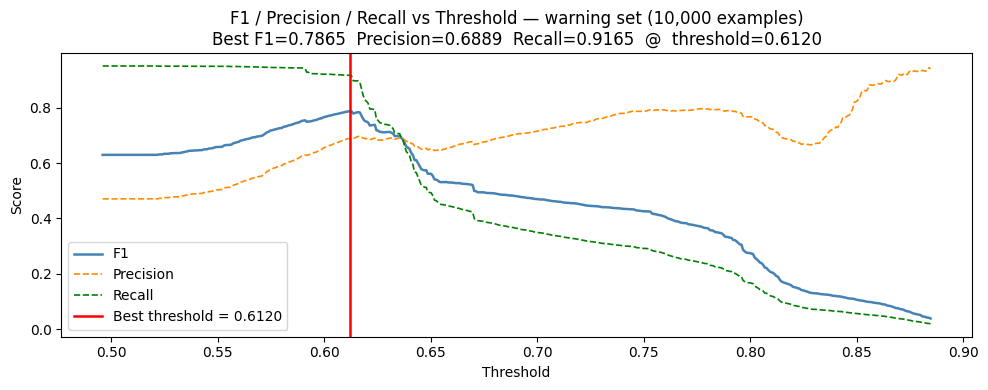

In [17]:
grid_thresholds = np.linspace(
    np.percentile(warning_scores, 5),
    np.percentile(warning_scores, 99),
    500
)

grid_results = []
for thr in grid_thresholds:
    y_pred = (warning_scores >= thr).astype(int)
    tp = int(((y_pred == 1) & (warning_labels == 1)).sum())
    fp = int(((y_pred == 1) & (warning_labels == 0)).sum())
    fn = int(((y_pred == 0) & (warning_labels == 1)).sum())
    prec   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_val = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    grid_results.append({"threshold": thr, "precision": prec, "recall": rec, "f1": f1_val})

grid_df   = pd.DataFrame(grid_results)
best_row  = grid_df.loc[grid_df["f1"].idxmax()]
THRESHOLD = best_row["threshold"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(grid_df["threshold"], grid_df["f1"],        color="steelblue",  lw=1.8, label="F1")
ax.plot(grid_df["threshold"], grid_df["precision"], color="darkorange", lw=1.2, ls="--", label="Precision")
ax.plot(grid_df["threshold"], grid_df["recall"],    color="green",      lw=1.2, ls="--", label="Recall")
ax.axvline(THRESHOLD, color="red", lw=1.8, label=f"Best threshold = {THRESHOLD:.4f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title(
    f"F1 / Precision / Recall vs Threshold — warning set ({WARNING_SET_SIZE:,} examples)\n"
    f"Best F1={best_row['f1']:.4f}  Precision={best_row['precision']:.4f}  "
    f"Recall={best_row['recall']:.4f}  @  threshold={THRESHOLD:.4f}"
)
ax.legend()
plt.tight_layout()
plt.savefig("warning_set_threshold_grid.png", dpi=150)
plt.show()

---

## Online unsupervised training


In [18]:
adwin_train = drift.ADWIN()
drift_events_train = []
train_scores_hst = list(warning_scores)
score_window  = deque(maxlen=500)
warmup_adwin  = 50

for i, (x, _) in enumerate(load_kdd(train_path, skip=WARNING_SET_SIZE)):
    score = model.score_one(x)
    train_scores_hst.append(score)

    adwin_train.update(score)
    if i >= warmup_adwin and adwin_train.drift_detected:
        drift_events_train.append((i + WARNING_SET_SIZE, score))
        adwin_train = drift.ADWIN()

    score_window.append(score)
    model.learn_one(x)

total_train = WARNING_SET_SIZE + i + 1
print(f"Training finished — {total_train} total examples processed.")
print(f"  Warning set : {WARNING_SET_SIZE}")
print(f"  Incremental : {i + 1}")
print(f"Drift events detected : {len(drift_events_train)}")
if drift_events_train:
    print(f"First {len(drift_events_train)} drift events (index, score):")
    for idx, sc in drift_events_train[:5]:
        print(f"  {idx} -> {sc:.6f}")

joblib.dump(model, "hst_model_nsl.pkl")
print("Model saved to hst_model_nsl.pkl")

Training finished — 125973 total examples processed.
  Warning set : 10000
  Incremental : 115973
Drift events detected : 2
First 2 drift events (index, score):
  62287 -> 0.678442
  75023 -> 0.685167
Model saved to hst_model_nsl.pkl


---

## Evaluation on test set


In [19]:
roc_auc   = river_metrics.ROCAUC()
f1        = river_metrics.F1()
precision = river_metrics.Precision()
recall    = river_metrics.Recall()
gmean     = river_metrics.GeometricMean()
cm        = river_metrics.ConfusionMatrix()

t_score_total = 0
n_test = 0

for x, y_true in load_kdd(test_path):
    t0 = time.perf_counter()
    score = model.score_one(x)
    t_score_total += time.perf_counter() - t0

    y_pred = 1 if score >= THRESHOLD else 0

    roc_auc.update(y_true, score)
    f1.update(y_true, y_pred)
    precision.update(y_true, y_pred)
    recall.update(y_true, y_pred)
    gmean.update(y_true, y_pred)
    cm.update(y_true, y_pred)

    n_test += 1

t_medio = (t_score_total / n_test) * 1000

tp = cm.data[1][1]
fp = cm.data[0][1]
tn = cm.data[0][0]
fn = cm.data[1][0]

print(f"Threshold  : {THRESHOLD:.4f}")
print(f"ROCAUC     : {roc_auc.get():.4f}")
print(f"Precision  : {precision.get():.4f}")
print(f"Recall     : {recall.get():.4f}")
print(f"F1         : {f1.get():.4f}")
print(f"G-Mean     : {gmean.get():.4f}")
print(f"TP={tp}  FP={fp}  TN={tn}  FN={fn}")
print(f"Avg Time   : {t_medio:.4f} ms/instância")
print(f"Memory     : {asizeof.asizeof(model) / 1024:.1f} KB")

Threshold  : 0.6120
ROCAUC     : 0.8145
Precision  : 0.8185
Recall     : 0.8382
F1         : 0.8282
G-Mean     : 0.7952
TP=10756.0  FP=2385.0  TN=7326.0  FN=2077.0
Avg Time   : 1.1201 ms/instância
Memory     : 25740.0 KB


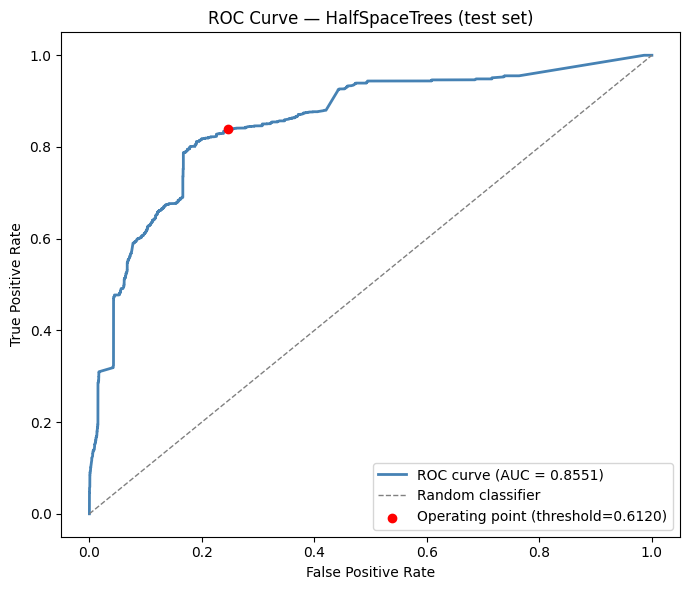

In [20]:
all_scores = []
all_labels = []
for x, y_true in load_kdd(test_path):
    all_scores.append(model.score_one(x))
    all_labels.append(y_true)

fpr, tpr, _ = roc_curve(all_labels, all_scores)
roc_auc_sk  = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc_sk:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random classifier")
ax.scatter(fp / (fp + tn), tp / (tp + fn), color="red", zorder=5,
           label=f"Operating point (threshold={THRESHOLD:.4f})")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — HalfSpaceTrees (test set)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_hst.png", dpi=150)
plt.show()

In [21]:
records = []

for i, (x, y_true) in enumerate(load_kdd(test_path)):
    score = model.score_one(x)
    y_pred = 1 if score >= THRESHOLD else 0
    row = {"index": i, "score": score, "y_true": y_true, "y_pred": y_pred}
    row.update(x)
    records.append(row)

scores_df = pd.DataFrame(records)
scores_df.to_csv("anomaly_scores_hst-nsl.csv", index=False)
print(f"anomaly_scores_hst-nsl.csv saved — {len(scores_df)} rows, {len(scores_df.columns)} columns.")

anomaly_scores_hst-nsl.csv saved — 22544 rows, 45 columns.


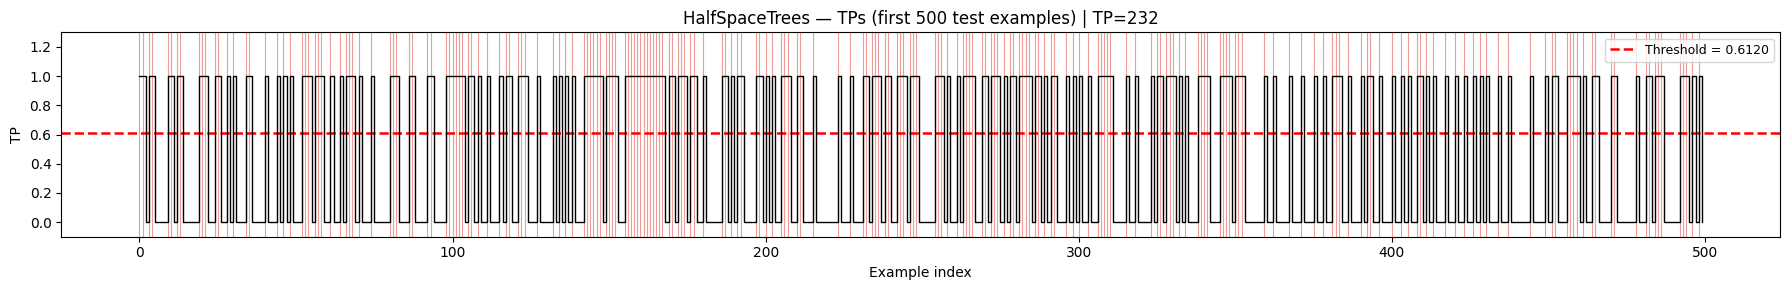

In [22]:
df_plot = pd.read_csv("anomaly_scores_hst-nsl.csv").iloc[:500]
test_scores = df_plot["score"].values
test_labels = df_plot["y_true"].values
indices     = df_plot["index"].values

fig, ax = plt.subplots(figsize=(18, 3))

y_pred_plot = (test_scores >= THRESHOLD).astype(int)
tp_signal   = ((test_labels == 1) & (y_pred_plot == 1)).astype(int)
tp_mask     = tp_signal.astype(bool)

for idx in indices[tp_mask]:
    ax.axvline(idx, color="#e53935", linewidth=0.8, alpha=0.5, zorder=1)

ax.step(indices, tp_signal, where="post", color="black", linewidth=1.0, zorder=3)
ax.axhline(THRESHOLD, color="red", linestyle="--", linewidth=1.8,
           label=f"Threshold = {THRESHOLD:.4f}")

ax.set_ylabel("TP")
ax.set_xlabel("Example index")
ax.set_title(f"HalfSpaceTrees — TPs (first 500 test examples) | TP={tp_signal.sum()}")
ax.set_ylim(-0.1, 1.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("anomaly_scores_tp_warningset_hst.png", dpi=150)
plt.show()